# Clustering

In this notebook we cover:

1. What clustering is
2. Distance metrics
3. Data preprocessing
4. K-Means and MiniBatch K-Means
5. Hierarchical clustering
6. Density-based clustering (DBSCAN / OPTICS)
7. Probabilistic clustering (GMM)
8. Evaluation and visualization

Goal:
Understand how to discover structure in data without labels.

## What is Clustering?

### Problem

We have data but no labels:

    X = features
    y = unknown

We want to discover structure in the data.

### Solution

Group similar data points:

    clusters = groups of similar samples

### Supervised vs Unsupervised

Supervised:
    input --> target known

Unsupervised:
    input --> no target

### Use Cases

- Customer segmentation
- Molecular similarity grouping
- Image segmentation
- Anomaly detection
- Document clustering

## Distance Metrics

Most clustering relies on similarity.

### Euclidean Distance

Straight-line distance:

    sqrt(Σ (xi - yi)²)

### Manhattan Distance

Grid-like distance:

    Σ |xi - yi|

### Cosine Similarity

Angle between vectors:

    measures direction, not magnitude

### Important Insight

Distance depends on:

- feature scaling
- feature selection

### Key Takeaway

Clustering =

    grouping based on distance

## Why Scaling Matters

Clustering depends on distance.

If one feature is larger:

--> it dominates the distance

Scaling ensures:

- equal importance of features
- stable clustering

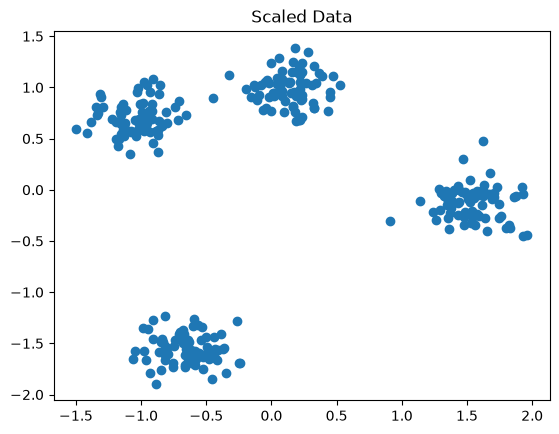

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# Generate clusterable data
X, _ = make_blobs(n_samples=300, centers=4, random_state=42)

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

plt.scatter(X_scaled[:,0], X_scaled[:,1])
plt.title("Scaled Data")
plt.show()

## K-Means Clustering

### Idea

Find cluster centers (centroids)

Assign each point to nearest center.

### Algorithm

1. Initialize centroids
2. Assign points
3. Update centroids
4. Repeat

### Objective

Minimize:

    within-cluster variance (inertia)

### Pros

- fast
- simple

### Cons

- need to choose K
- sensitive to outliers

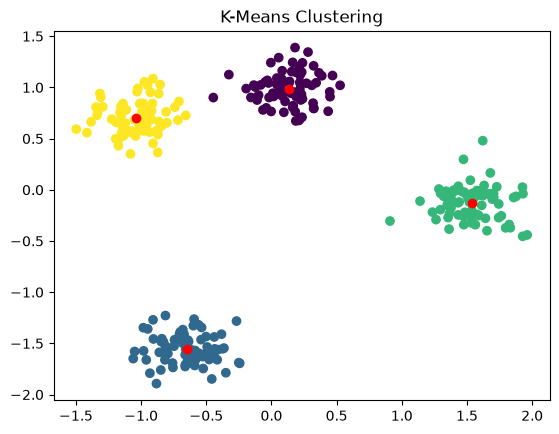

In [2]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X_scaled)

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels)
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            color='red')
plt.title("K-Means Clustering")
plt.show()

## Elbow Method — Choosing the Number of Clusters

### 1. Problem

In K-Means, we must choose:

    number of clusters K

But:

--> there are no labels (unsupervised learning)  
--> no obvious correct value  

### 2. Core Idea

We evaluate clustering quality using:

    Inertia (within-cluster variance)

- lower inertia --> tighter clusters  
- higher inertia --> worse clustering  

### 3. How It Works

1. Run K-Means for different values of K  
2. Compute inertia for each K  
3. Plot:

       K vs Inertia

### 4. Interpretation

- Inertia always decreases as K increases  
- At some point, improvement slows down  

--> this point creates a "bend" in the curve:

    the **elbow**


### 5. Intuition

- small K --> big improvement  
- large K --> only small improvements  

--> optimal K = point where adding more clusters
  does not significantly improve clustering  


### 6. Limitation

- not always a clear elbow  
- requires visual judgment  

### 7. Takeaway

Elbow method =

    find the point where additional clusters give diminishing returns


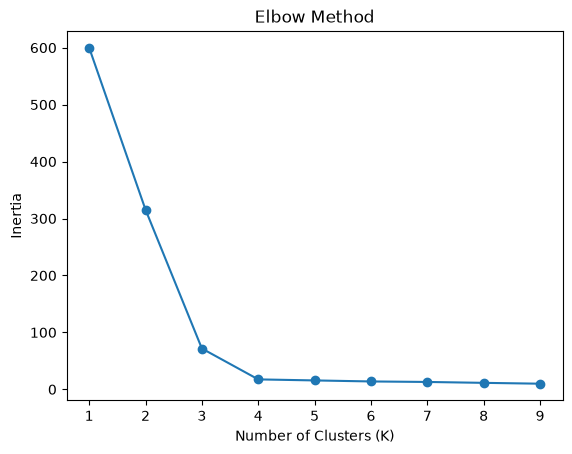

In [3]:
inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


## Mini-Batch K-Means

### Idea

Use small random batches instead of full dataset

### Benefit

- faster on large data
- approximate solution

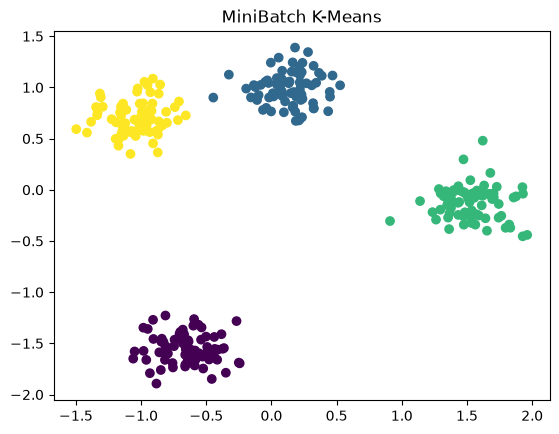

In [4]:
from sklearn.cluster import MiniBatchKMeans

mb = MiniBatchKMeans(n_clusters=4)
labels = mb.fit_predict(X_scaled)

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels)
plt.title("MiniBatch K-Means")
plt.show()

## Agglomerative Clustering

### Idea

Merge clusters step-by-step

### Linkage Methods

- Ward --> minimize variance
- Complete --> max distance
- Average --> mean distance
- Single --> nearest point

### Pros

- hierarchical structure

### Cons

- slow

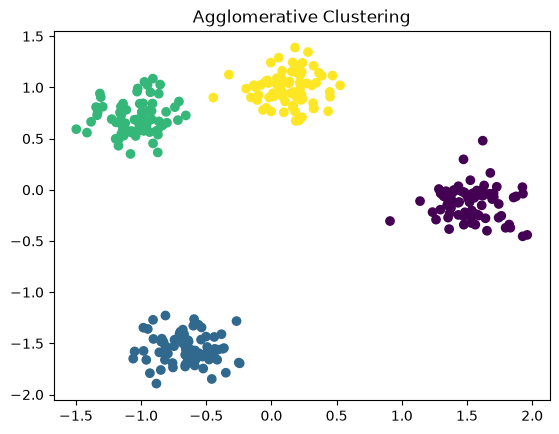

In [5]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=4)
labels = agg.fit_predict(X_scaled)

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels)
plt.title("Agglomerative Clustering")
plt.show()

## DBSCAN

### Idea

Clusters = dense regions

### Points

- Core (dense)
- Border
- Noise

### Pros

- no need for K
- finds arbitrary shapes
- detects outliers

### Cons

- sensitive to eps parameter

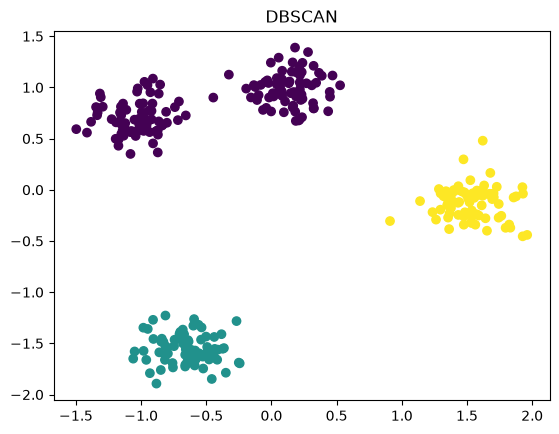

In [6]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=5)
labels = db.fit_predict(X_scaled)

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels)
plt.title("DBSCAN")
plt.show()

## OPTICS

---

Improves DBSCAN:

- handles varying densities
- more robust clustering structure

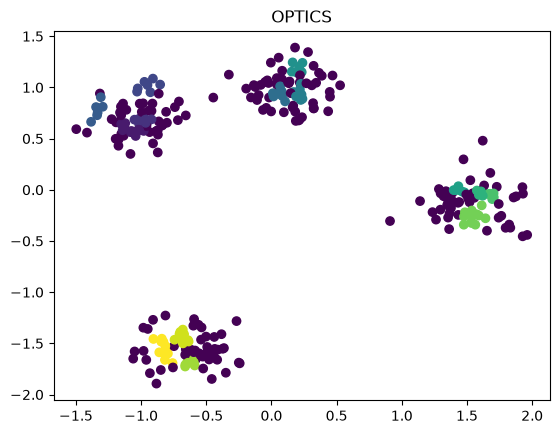

In [7]:
from sklearn.cluster import OPTICS

optics = OPTICS()
labels = optics.fit_predict(X_scaled)

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels)
plt.title("OPTICS")
plt.show()

## Gaussian Mixture Models

### Idea

Clusters are probability distributions

### Key Difference

K-Means:
    hard assignment

GMM:
    soft assignment (probabilities)

### Output

P(cluster | x)

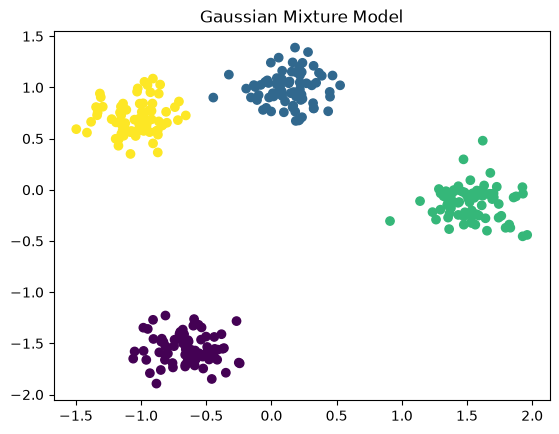

In [8]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=4)
labels = gmm.fit_predict(X_scaled)

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels)
plt.title("Gaussian Mixture Model")
plt.show()

## Cluster Evaluation

### Silhouette Score

Measures:

- separation between clusters
- cohesion within clusters

Range:

- +1 --> perfect clustering
- 0 --> overlapping clusters
- -1 --> wrong clustering

In [9]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.7974739889632732


## Visualization

High-dimensional data is hard to visualize.

We reduce dimensions using:

- PCA --> linear projection
- t-SNE --> nonlinear mapping

### Goal

Visualize cluster structure

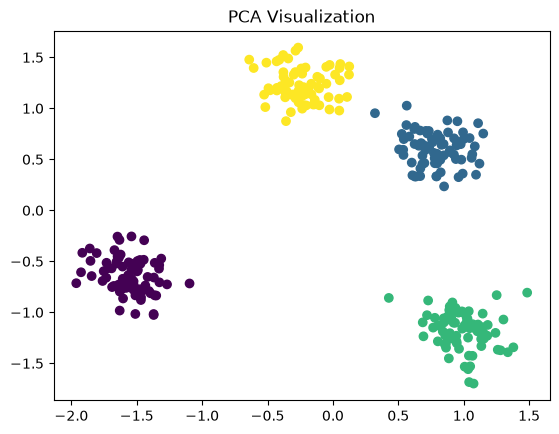

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_scaled)

plt.scatter(X_reduced[:,0], X_reduced[:,1], c=labels)
plt.title("PCA Visualization")
plt.show()

## Choosing the Right Clustering Algorithm

| Scenario | Algorithm |
|----------|----------|
| Spherical clusters | K-Means |
| Hierarchical structure | Agglomerative |
| Outlier detection | DBSCAN |
| Varying densities | OPTICS |
| Probabilistic clusters | GMM |